# Caracteristicas musicales


A lo largo de este documento, se analizaran las relaciones existentes entre las dirferentes caracteristicas musicales que posee el dataset, asi mismo, se intentara dar una respuesta a las preguntas:

1. ¿Existen grupos naturales de canciones con características similares?
2. ¿Qué características presentan las correlaciones más fuertes?
3. ¿Las canciones con alta danceability también suelen tener alta energy?
4 ¿Existe relación entre valence (positividad emocional) y popularidad?
5. ¿Qué variables explican mejor la variabilidad musical del conjunto de datos?
6. ¿Es posible identificar géneros o estilos únicamente a partir de características acústicas?

<hr />

### 0. Analisis general del comportamiento de variables
Para responder a esta pregunta, se analizaran las diversas distribuciones de las caracteristicas musicales con el fin de poder entender su coomportamiento y agruparlas entre si.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


datos = pd.read_csv('../dataset/main_dataset.csv', usecols=['track_uri','popularity','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','valence','tempo','duration_ms','time_signature','liveness'])


In [2]:
datos.head()

,track_uri,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,0,0.611,0.614,5.0,-8.815,0.0,0.0672,0.0169,0.000794,0.7530,0.520,128.050,195000.0,4.0
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,33,0.638,0.781,4.0,-6.848,0.0,0.0285,0.0118,0.009530,0.3490,0.250,122.985,194641.0,4.0
2,spotify:track:2CY92qejUrhyPUASawNVRr,52,0.560,0.810,0.0,-8.029,0.0,0.0872,0.0071,0.000008,0.2410,0.247,170.044,217573.0,4.0
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,0,0.525,0.699,9.0,-4.571,1.0,0.0353,0.0178,0.000088,0.0888,0.199,92.011,443478.0,4.0
4,spotify:track:3yUJKPsjvThlcQWTS9ttYx,0,0.367,0.771,9.0,-5.863,1.0,0.1060,0.3650,0.000001,0.0965,0.163,115.917,225862.0,4.0


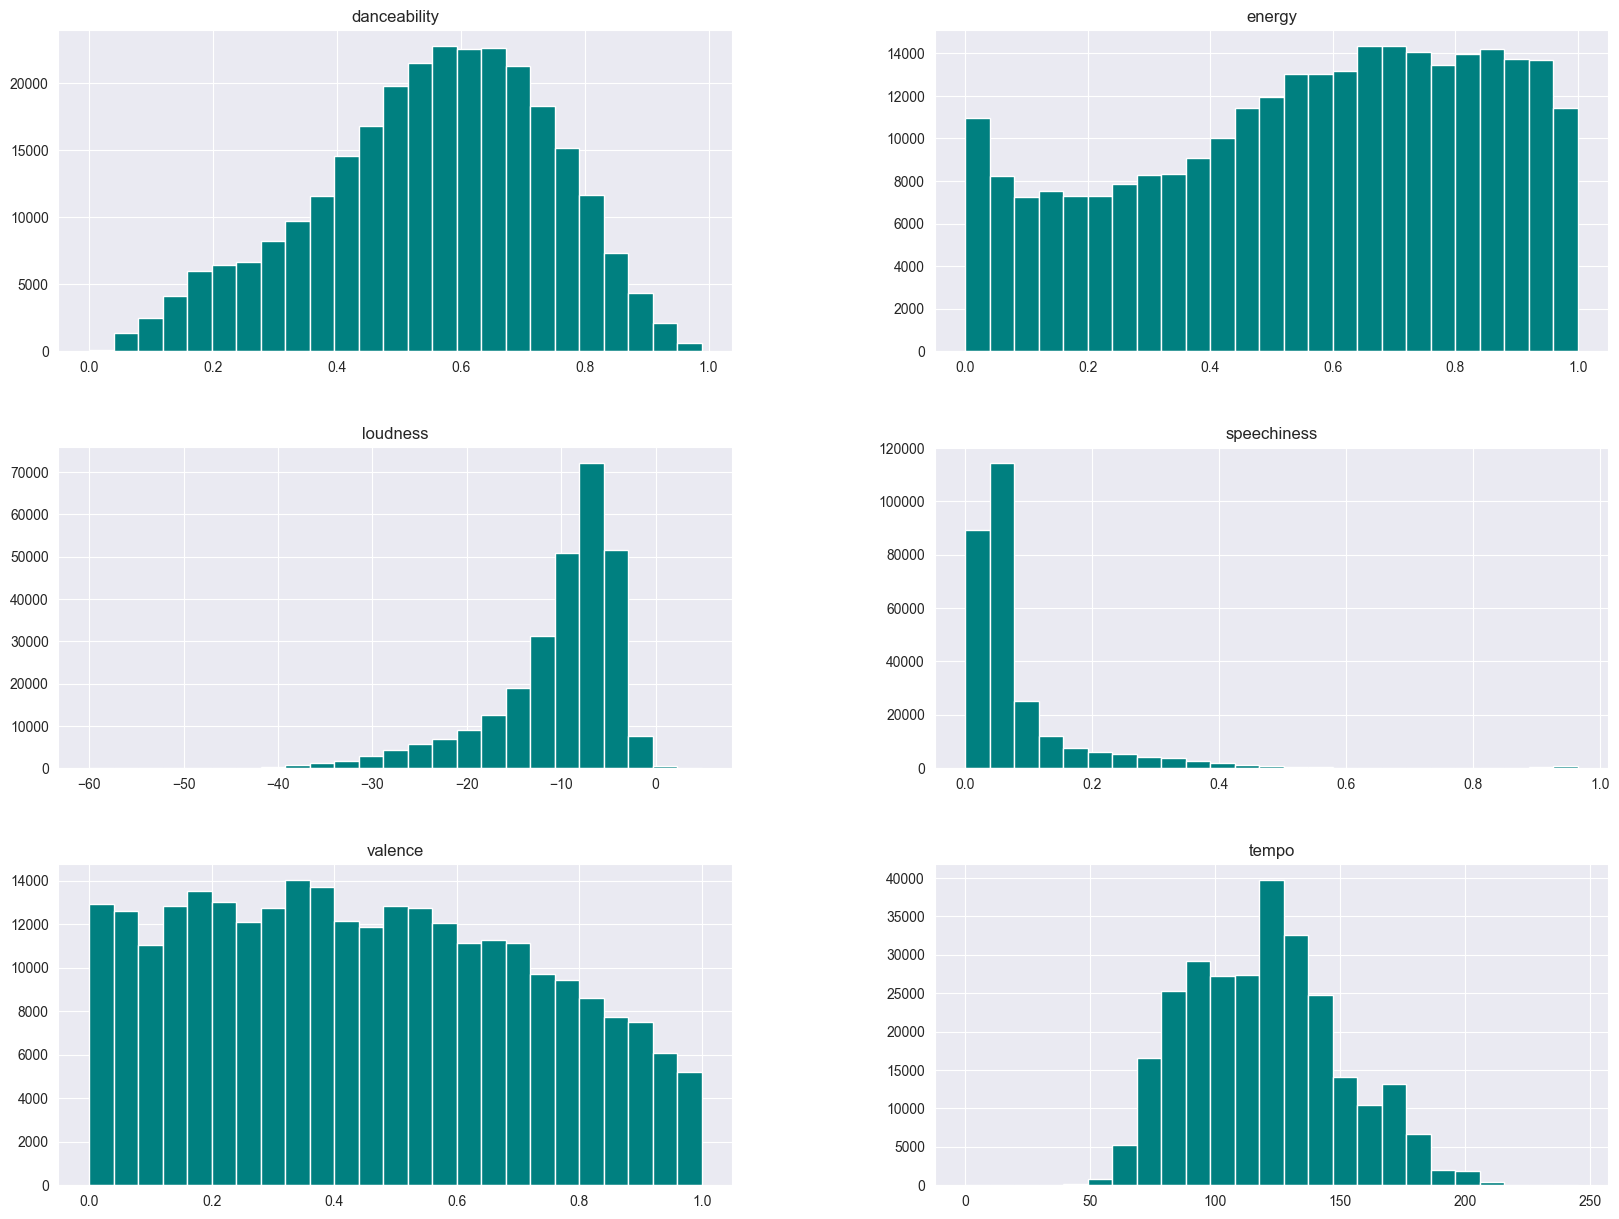

In [3]:
sns.set_style('darkgrid')
columnas_de_interes = datos[['danceability','energy','loudness','speechiness','valence','tempo']]
columnas_de_interes.hist(figsize=(20,15), color='teal', bins=25)

plt.show()

## Para danceability)
Debido a que aparente mente presenta una distribucion normal, tomaremos una muestra de 500 datos y aplicaremos la prueba de kolmogorov-Srmirnov para tener resolapdo estadistico de si una distribucion es normal o no.




In [4]:
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

scaler = StandardScaler()

muestra =  (
    columnas_de_interes['danceability']
    .sample(n=800, random_state=777)
    .values.reshape(-1,1))

muestra_est = scaler.fit_transform(muestra)

ks_stat, ks_p_value = stats.kstest(muestra_est.flatten(), 'norm')

print(f"Estadistico KS: {ks_stat:.4f}")
print(f"Valor p: {ks_p_value:.4f}")
if ks_p_value > 0.05:
    print("Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).")
else:
    print(
        "Resultado: Los datos NO siguen una distribución normal (p <= 0.05)."
    )


Estadistico KS: 0.0453
Valor p: 0.0727
Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).


La observación de que el atributo de *danceability* en Spotify sigue una distribución normal permite inferir que
la mayor parte de las canciones posee un nivel moderado, lo que sugiere que, en general, las personas
pueden mover la cabeza o los pies al escucharlas. Sin embargo, la cola derecha de la distribución indica que solo
una pequeña proporción de canciones alcanza un grado de danceability alto, lo que permitiría a los usuarios
comprometerse plenamente con la danza. Este patrón refuerza la idea de que, aunque la mayoría de las canciones
están diseñadas para ser disfrutadas de manera dinámica, la experiencia de "bailar sin reservas" es una rareza
estadística. Dicho de otra forma, **pocas canciones dentro del catalogo se pueden bailar de forma tradicional**.

### Para speechiness)


Text(0.5, 1.0, 'Grafica de speechiness')

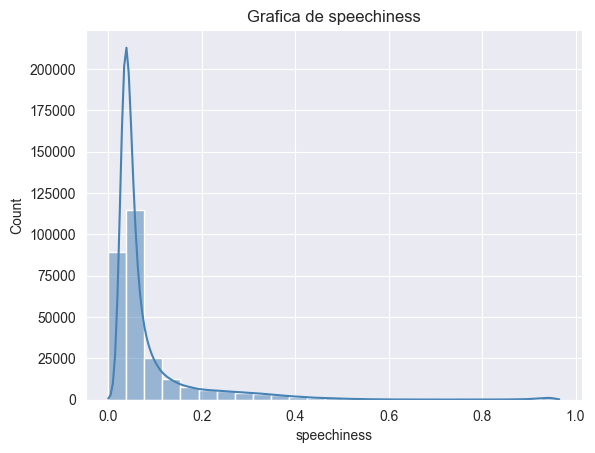

In [5]:
sns.histplot(datos, x='speechiness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de speechiness')

La variable *speechiness* en Spotify sigue una distribución exponencial, lo que refleja que la mayoría de las canciones presentan un alto contenido vocal, destacando el predominio del canto en la música
de la plataforma. Sin embargo, la cola derecha de la distribución resalta la presencia de géneros como el hip-hop y el rap, en los que la *speechiness* alcanza valores extremadamente altos. Este patrón
subraya la diversidad estilística dentro del catálogo musical, evidenciando que, aunque la vocalización es un rasgo generalizado, su intensidad varía significativamente entre géneros. Esta característica
estadística puede ser útil para análisis de segmentación o recomendaciones basadas en preferencias estilísticas

### Para loudness)




Text(0.5, 1.0, 'Grafica de loudness')

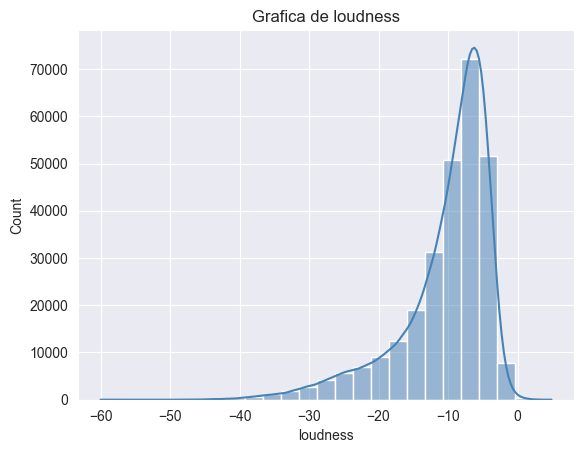

In [9]:
sns.histplot(datos, x='loudness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de loudness')

La variable *loudness* en Spotify presenta una distribución sesgada a la derecha, lo que indica que la mayoría de las canciones tienen un nivel de volumen moderado, sin alcanzar valores extremos. Sin
embargo, la cola derecha de la distribución revela la presencia de un pequeño número de canciones con niveles de volumen cercanos a 0 dB, asociadas principalmente a géneros como el rock, el metal y otros
estilos con alta intensidad sonora. Por otro lado, la cola izquierda —de mayor extensión— refleja la predominancia de géneros más relajados, cuya característica distintiva es un volumen bajo o moderado.
Este patrón resalta la diversidad en los niveles de *loudness* dentro del catálogo musical, evidenciando que, aunque la mayoría de las canciones se ubica en un rango intermedio, existen variaciones
significativas entre géneros que pueden ser aprovechadas en análisis de segmentación, los cuales se abordaran mas adelante

### Comparacion de variables 
